In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.tsa.api as smt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox

In [2]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC', result_object=False)
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [4]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (7, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0), rowspan=2)
        pacf_ax = plt.subplot2grid(layout, (4, 0), rowspan=2)
        qq_ax = plt.subplot2grid(layout, (6, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)
        sm.qqplot(y, line='s', ax=qq_ax)

        plt.tight_layout()
    return

### Sales of Company X

Results of Dickey-Fuller Test:
Test Statistic                  0.654715
p-value                         0.988889
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


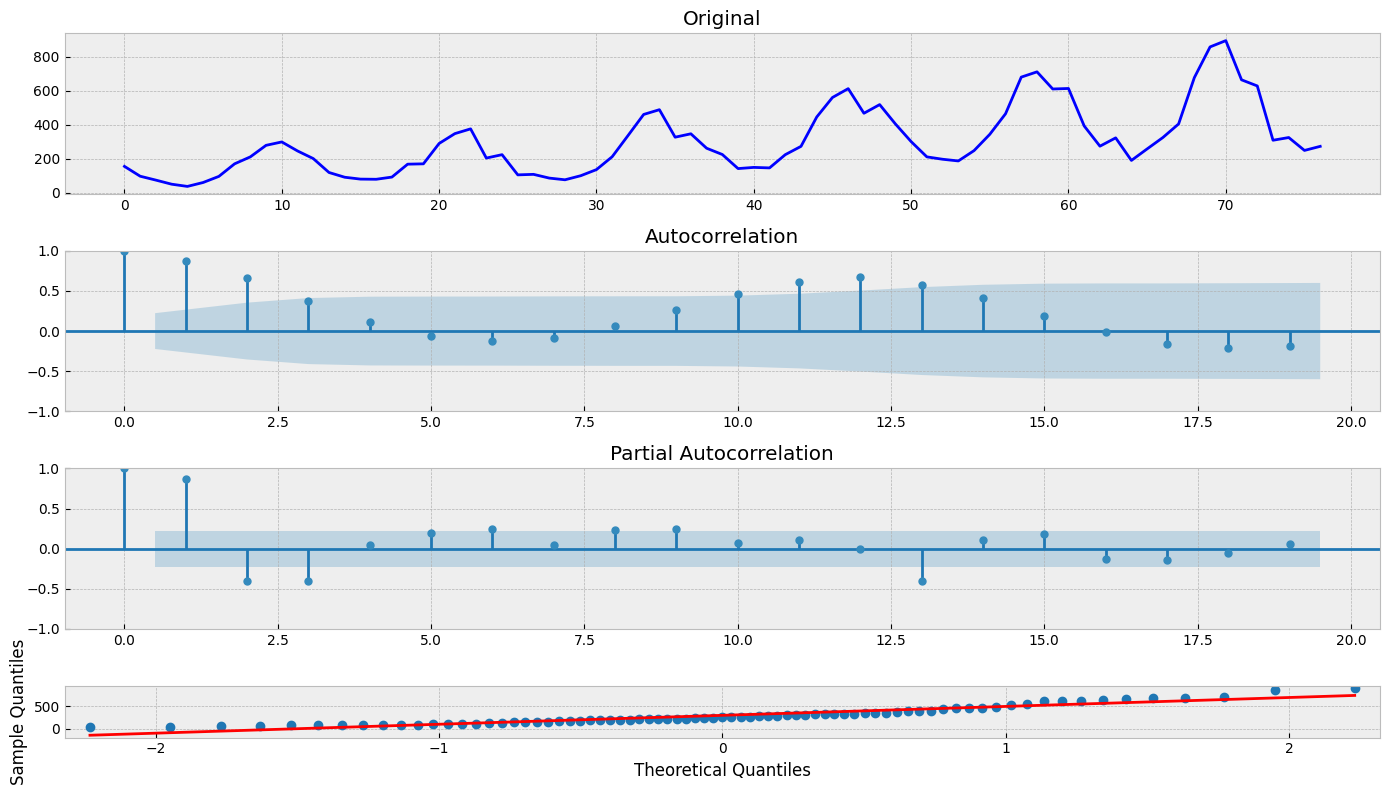

In [5]:
series = np.asarray(pd.read_csv("monthly-sales-of-company-x-jan-6.csv")['Count'])
tsplot(series)

Заметна увеличивающаяся дисперсия, что выражается в амплитуде колебаний. Для нормализации дисперсии прприменим boxcox:

Results of Dickey-Fuller Test:
Test Statistic                  -1.326071
p-value                          0.617162
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


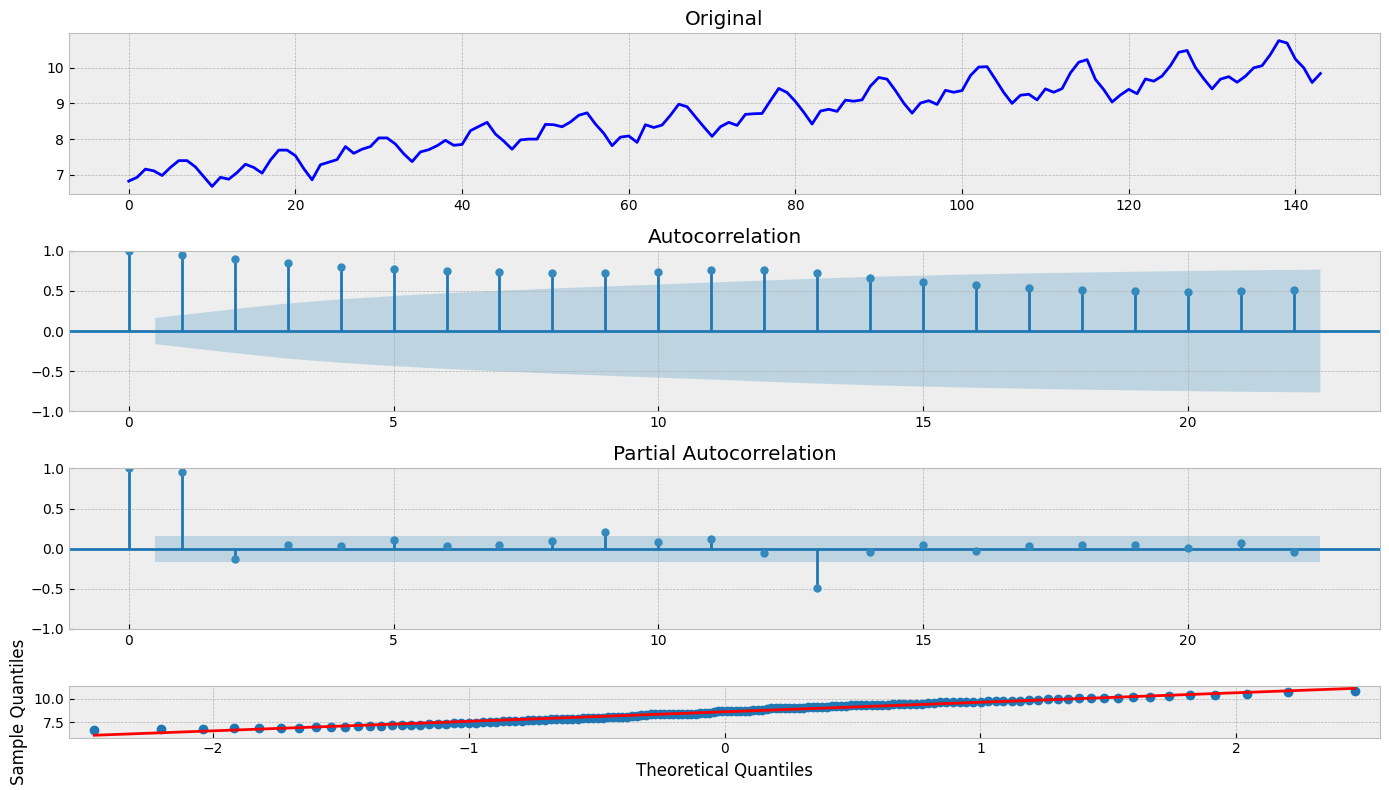

In [6]:
series = np.asarray(pd.read_csv("international-airline-passengers.csv")['Count'])
series = boxcox(series)[0]
tsplot(series)

Для обучения модели GARCH возьмем оптимальные параметры от модели ARIMA. Для автоматического подбора параметров ARIMA будем использовать pmdarima

In [7]:
# Загружаем модуль ARIMA
from statsmodels.tsa.arima.model import ARIMA

In [8]:
!pip install pmdarima
import pmdarima as pm

In [9]:
# Автоматический подбор параметров
auto_model = pm.auto_arima(
    y=series,
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    d=None,           # d определится автоматически тестами на стационарность
    seasonal=False,   # если ряд сезонный, поставьте True
    trace=True        # показывает процесс перебора в консоли
)

print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-5.732, Time=0.89 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5.735, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=0.846, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1.576, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4.796, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=2.38 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=3.80 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-3.929, Time=0.82 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-1.557, Time=0.44 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=4.26 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-6.804, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-2.848, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-0.432, Time=0.07 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-16.289, Time=0.46 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-2.552, Time=0.13 sec
 ARIMA(3

In [10]:
mdl = ARIMA(series, order=auto_model.order, trend='t').fit()

Строим график остатков предсказания:

Results of Dickey-Fuller Test:
Test Statistic                  -3.186776
p-value                          0.020763
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


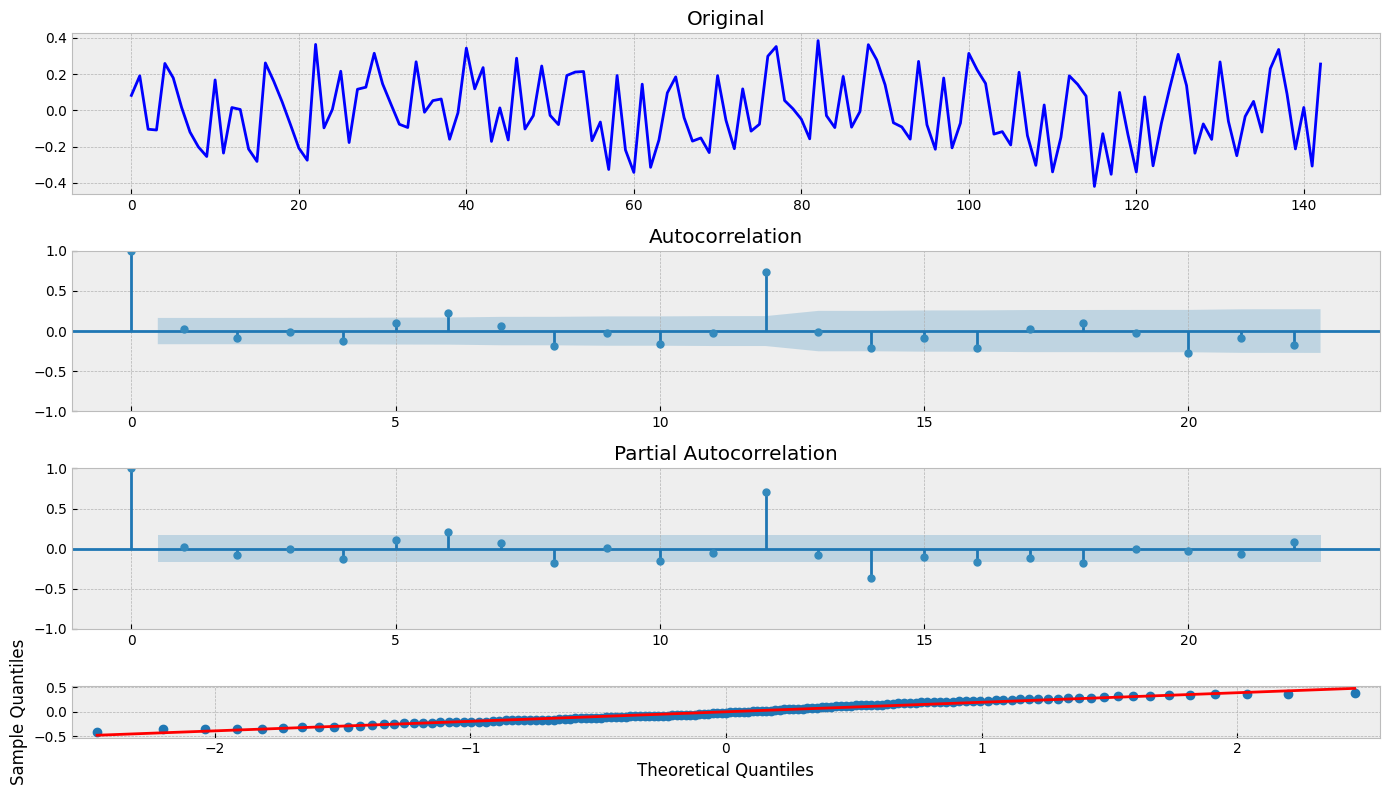

In [11]:
tsplot(mdl.resid[1:])

Для GARCH делаем ряд стационарным сезонной дифференциацией с лагом 12 и дифференциацией с лагом 1:

Results of Dickey-Fuller Test:
Test Statistic                  -4.393873
p-value                          0.000304
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64


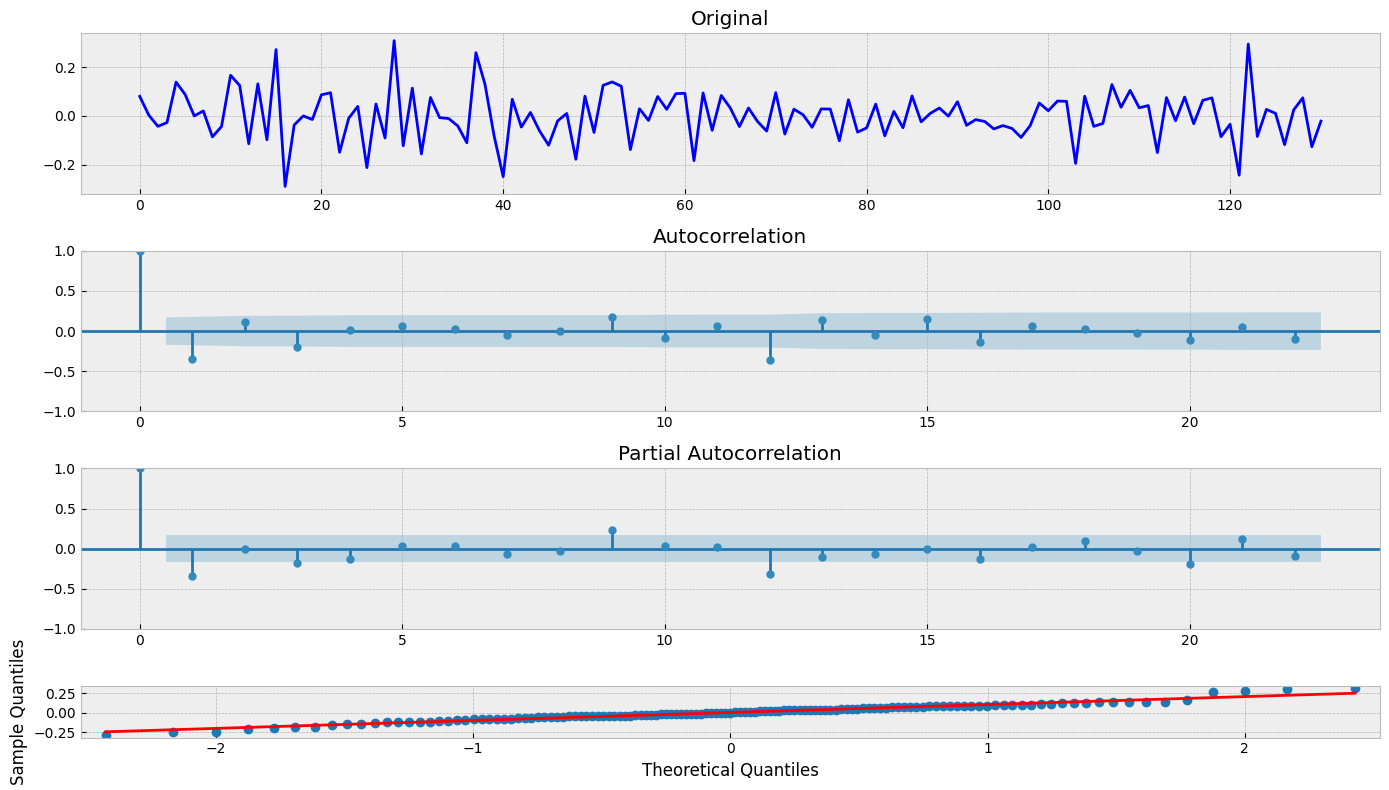

In [12]:
series = series[12:] - series[:-12]
series = series[1:] - series[:-1]
tsplot(series)

Обучаем модель GARCH с найденными оптимальными параметрами для ARIMA:

In [13]:
# Загрузка модуля GARCH
!pip install arch

from arch import arch_model

In [14]:
# Now we can fit the arch model using the best fit arima model parameters
p_ = auto_model.order[0]
o_ = auto_model.order[1]
q_ = auto_model.order[2]

# Using student T distribution usually provides better fit
am = arch_model(series, p=p_, o=o_, q=q_, dist='StudentsT', rescale=True)
res = am.fit(update_freq=5, disp='off')
print(res.summary())

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -179.288
Distribution:      Standardized Student's t   AIC:                           378.575
Method:                  Maximum Likelihood   BIC:                           407.327
                                              No. Observations:                  131
Date:                      Sun, Oct 04 2026   Df Residuals:                      130
Time:                              18:14:10   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

Results of Dickey-Fuller Test:
Test Statistic                  -4.393873
p-value                          0.000304
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64


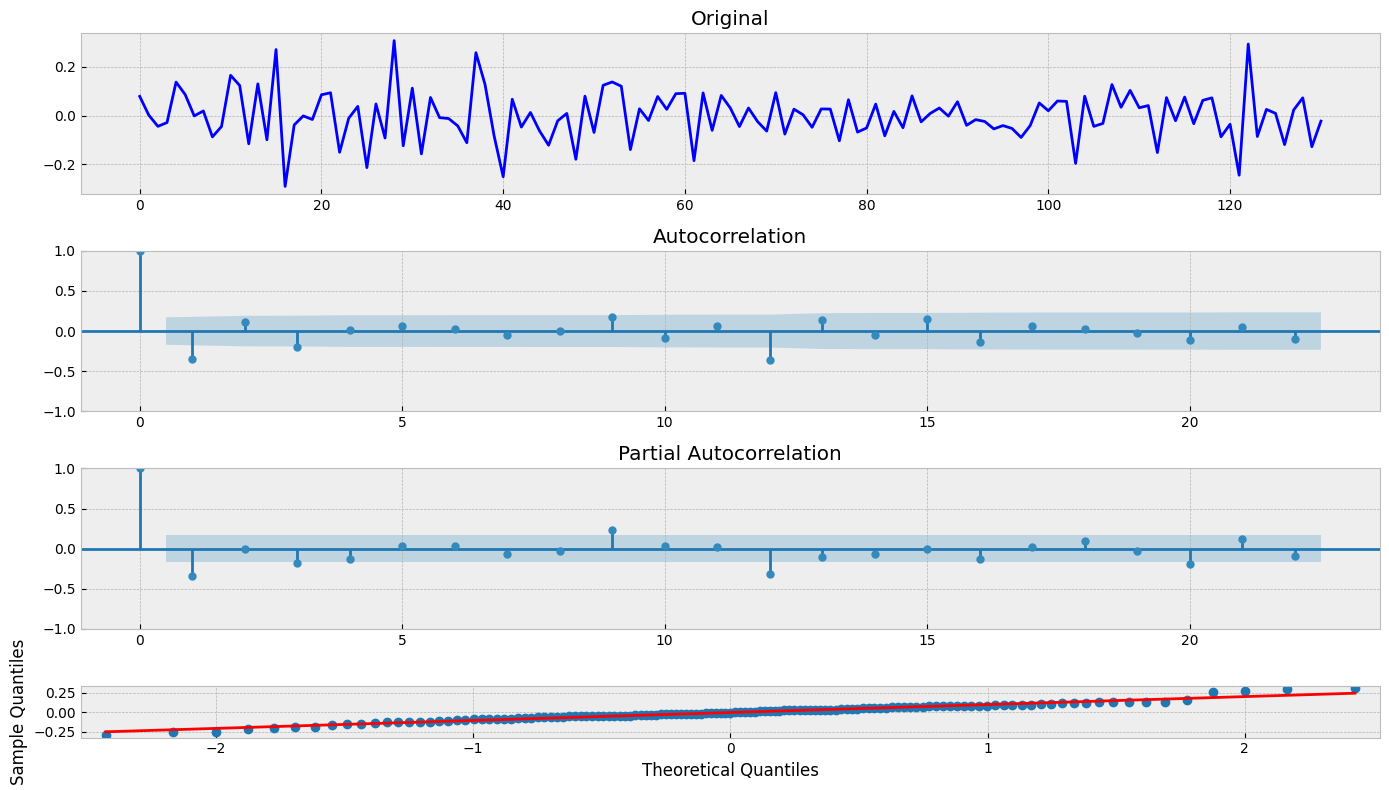

In [15]:
tsplot(res.resid / res.scale)

Графики подготовленного для модели ряда и остатков в модели практически совпадают (с точностью до масштабного коэффициента). Это говорит, что средние значения близки к нулю.

Выведем прогноз волатильности обученной модели GARCH

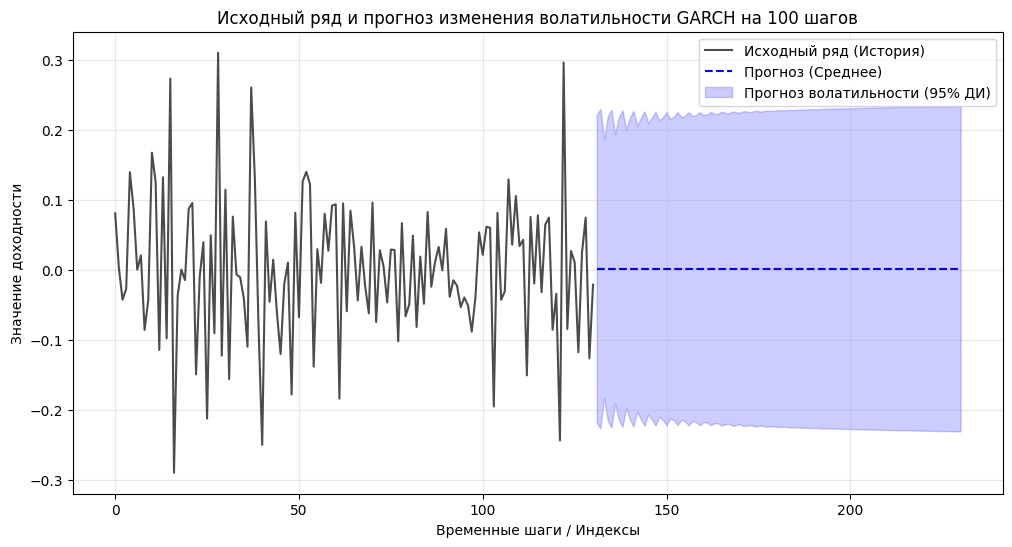

In [16]:
# Делаем прогноз на 100 шагов вперед
horizon = 100
forecast = res.forecast(horizon=horizon)

# Достаем прогноз условной дисперсии для последнего дня
pred_variance_scaled = forecast.residual_variance.iloc[-1].values

# ВОЗВРАЩАЕМ К ИСХОДНОМУ МАСШТАБУ И РАЗМЕРНОСТИ
# Переводим дисперсию в стандартное отклонение (корень) и делим на res.scale
pred_volatility = np.sqrt(pred_variance_scaled) / res.scale

# Получаем прогноз среднего (возвращаем к исходному масштабу)
pred_mean = forecast.mean.iloc[-1].values / res.scale

# Строим правильные индексы для оси X (для продолжения графика вправо)
n_samples = len(series)
history_indices = np.arange(n_samples)
future_indices = np.arange(n_samples, n_samples + horizon)

# Считаем границы 95% коридора волатильности
lower_bound = pred_mean - 1.96 * pred_volatility
upper_bound = pred_mean + 1.96 * pred_volatility

# Визуализация
plt.figure(figsize=(12, 6))

# Рисуем историю
plt.plot(history_indices, series, label='Исходный ряд (История)', color='black', alpha=0.7)

# Рисуем линию прогноза среднего значения
plt.plot(future_indices, pred_mean, label='Прогноз (Среднее)', color='blue', linestyle='--')

# Закрашиваем будущую волатильность (95% доверительный интервал)
plt.fill_between(future_indices, lower_bound, upper_bound, color='blue', alpha=0.2, label='Прогноз волатильности (95% ДИ)')

plt.title('Исходный ряд и прогноз изменения волатильности GARCH на 100 шагов')
plt.xlabel('Временные шаги / Индексы')
plt.ylabel('Значение доходности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()